# Cross-Classifying by More than One Variable

When individuals have multiple features, there are many different ways to classify them. For example, if we have a population of college students for each of whom we have recorded a major and the number of years in college, then the students could be classified by major, or by year, or by a combination of major and year.

Pandas allows us to classify individuals according to multiple variables using `groupby` and pivot table operations. This is called *cross-classifying*.

In [1]:
import pandas as pd
path_data = "../../../assets/data/"
import numpy as np

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")

## Two Variables: Counting the Number in Each Paired Category

The DataFrame `more_cones` records the flavor, color, and price of six ice cream cones.

In [2]:
more_cones = pd.DataFrame({
    "Flavor": ["strawberry", "chocolate", "chocolate", "strawberry", "chocolate", "bubblegum"],
    "Color": ["pink", "light brown", "dark brown", "pink", "dark brown", "pink"],
    "Price": [3.55, 4.75, 5.25, 5.25, 5.25, 4.75]
})
more_cones

,Flavor,Color,Price
0,strawberry,pink,3.55
1,chocolate,light brown,4.75
2,chocolate,dark brown,5.25
3,strawberry,pink,5.25
4,chocolate,dark brown,5.25
5,bubblegum,pink,4.75


We know how to count the number of cones of each flavor using `groupby`.

In [3]:
more_cones.groupby("Flavor").size().reset_index(name="count")

,Flavor,count
0,bubblegum,1
1,chocolate,3
2,strawberry,2


But now each cone has a color as well. To classify the cones by both flavor and color, we group by both columns. The resulting DataFrame has one row for every unique combination of values that appears in the grouped columns.

Although there are six cones, there are only four unique combinations of flavor and color. Two of the cones were dark brown chocolate, and two were pink strawberry.

In [4]:
more_cones.groupby(["Flavor", "Color"]).size().reset_index(name="count")

,Flavor,Color,count
0,bubblegum,pink,1
1,chocolate,dark brown,2
2,chocolate,light brown,1
3,strawberry,pink,2


## Two Variables: Finding a Characteristic of Each Paired Category

We can aggregate the remaining columns after grouping.

In [5]:
more_cones.groupby(["Flavor", "Color"], as_index=False)["Price"].sum()

,Flavor,Color,Price
0,bubblegum,pink,4.75
1,chocolate,dark brown,10.50
2,chocolate,light brown,4.75
3,strawberry,pink,8.80


**Three or More Variables.** You can use `groupby` with three or more categorical variables by including all of them in the list of grouping columns. However, cross-classifying by many variables can become complex because the number of distinct combinations can grow quickly.

## Pivot Tables: Rearranging the Output of `groupby`

Many uses of cross-classification involve just two categorical variables, like `Flavor` and `Color`. In these cases, pandas pivot tables make it easier to work with data classified according to two variables.

In [6]:
more_cones.groupby(["Flavor", "Color"]).size().reset_index(name="count")

,Flavor,Color,count
0,bubblegum,pink,1
1,chocolate,dark brown,2
2,chocolate,light brown,1
3,strawberry,pink,2


The same data can be displayed differently using a pivot table. Ignore the code for a moment, and just examine the table of outcomes.

In [7]:
pd.crosstab(more_cones["Color"], more_cones["Flavor"])

Flavor,bubblegum,chocolate,strawberry
Color,,,
dark brown,0,2,0
light brown,0,1,0
pink,1,0,2


Notice how this table displays all possible flavor-color combinations that appear in the data. The counts appear in the body of the table. To find the number of light brown chocolate cones, locate the `light brown` row and the `chocolate` column.

**Pivot Tables**

Pivot tables are closely related to grouping operations. They organize grouped values into a grid. One variable determines the columns, another determines the rows, and the values placed in the grid can be counts or aggregated numerical values.

In [8]:
pd.pivot_table(more_cones, values="Price", index="Color", columns="Flavor", aggfunc="sum", fill_value=0)

Flavor,bubblegum,chocolate,strawberry
Color,,,
dark brown,0.00,10.50,0.0
light brown,0.00,4.75,0.0
pink,4.75,0.00,8.8


And here is `groupby` doing the same calculation.

In [9]:
more_cones.groupby(["Flavor", "Color"], as_index=False)["Price"].sum()

,Flavor,Color,Price
0,bubblegum,pink,4.75
1,chocolate,dark brown,10.50
2,chocolate,light brown,4.75
3,strawberry,pink,8.80


Though the numbers in both tables are the same, the pivot table is often easier to read and compare.

## Example: Education and Income of Californian Adults

The State of California Open Data Portal provides information about educational attainment and personal income among Californians. We will study only the data for the year 2014.

In [10]:
full_table = pd.read_csv(path_data + 'educ_inc.csv')
ca_2014 = full_table[(full_table['Year'] == '1/1/14 0:00') & (full_table['Age'] != '00 to 17')]
ca_2014

,Year,Age,Gender,Educational Attainment,Personal Income,Population Count
885,1/1/14 0:00,18 to 64,Female,No high school diploma,"H: 75,000 and over",2058
886,1/1/14 0:00,65 to 80+,Male,No high school diploma,"H: 75,000 and over",2153
894,1/1/14 0:00,65 to 80+,Female,No high school diploma,"G: 50,000 to 74,999",4666
895,1/1/14 0:00,65 to 80+,Female,High school or equivalent,"H: 75,000 and over",7122
896,1/1/14 0:00,65 to 80+,Female,No high school diploma,"F: 35,000 to 49,999",7261
...,...,...,...,...,...,...
1021,1/1/14 0:00,18 to 64,Female,High school or equivalent,"A: 0 to 4,999",670294
1022,1/1/14 0:00,18 to 64,Male,Bachelor's degree or higher,"G: 50,000 to 74,999",682425
1023,1/1/14 0:00,18 to 64,Female,No high school diploma,"A: 0 to 4,999",723208
1024,1/1/14 0:00,18 to 64,Female,Bachelor's degree or higher,"H: 75,000 and over",953282


Each row corresponds to a combination of age, gender, educational level, and income. As a first step, we will focus on educational attainment and personal income.

In [11]:
educ_inc = ca_2014[['Educational Attainment', 'Personal Income', 'Population Count']]
educ_inc

,Educational Attainment,Personal Income,Population Count
885,No high school diploma,"H: 75,000 and over",2058
886,No high school diploma,"H: 75,000 and over",2153
894,No high school diploma,"G: 50,000 to 74,999",4666
895,High school or equivalent,"H: 75,000 and over",7122
896,No high school diploma,"F: 35,000 to 49,999",7261
...,...,...,...
1021,High school or equivalent,"A: 0 to 4,999",670294
1022,Bachelor's degree or higher,"G: 50,000 to 74,999",682425
1023,No high school diploma,"A: 0 to 4,999",723208
1024,Bachelor's degree or higher,"H: 75,000 and over",953282


Let's start by looking at educational level alone. We group by `Educational Attainment` and sum the population counts in each category.

In [12]:
education = educ_inc[['Educational Attainment', 'Population Count']]
educ_totals = education.groupby('Educational Attainment', as_index=False)['Population Count'].sum()
educ_totals

,Educational Attainment,Population Count
0,Bachelor's degree or higher,8525698
1,"College, less than 4-yr degree",7775497
2,High school or equivalent,6294141
3,No high school diploma,4258277


There are only four categories of educational attainment. The counts are so large that percentages are often easier to interpret.

In [13]:
def percents(array_x):
    return np.round((array_x / np.sum(array_x)) * 100, 2)

We now have the distribution of educational attainment among adult Californians.

In [14]:
educ_distribution = educ_totals.assign(**{'Population Percent': percents(educ_totals['Population Count'])})
educ_distribution

,Educational Attainment,Population Count,Population Percent
0,Bachelor's degree or higher,8525698,31.75
1,"College, less than 4-yr degree",7775497,28.96
2,High school or equivalent,6294141,23.44
3,No high school diploma,4258277,15.86


By using a pivot table, we can get a contingency table of adult Californians cross-classified by educational attainment and personal income.

In [15]:
totals = pd.pivot_table(educ_inc, values='Population Count', index='Personal Income', columns='Educational Attainment', aggfunc='sum', fill_value=0).reset_index()
totals

Educational Attainment,Personal Income,Bachelor's degree or higher,"College, less than 4-yr degree",High school or equivalent,No high school diploma
0,"A: 0 to 4,999",575491,985011,1161873,1204529
1,"B: 5,000 to 9,999",326020,810641,626499,597039
2,"C: 10,000 to 14,999",452449,798596,692661,664607
3,"D: 15,000 to 24,999",773684,1345257,1252377,875498
4,"E: 25,000 to 34,999",693884,1091642,929218,464564
5,"F: 35,000 to 49,999",1122791,1112421,782804,260579
6,"G: 50,000 to 74,999",1594681,883826,525517,132516
7,"H: 75,000 and over",2986698,748103,323192,58945


Each column of counts is a distribution of personal income at a specific level of educational attainment. Converting the counts to percentages allows us to compare the four distributions.

In [16]:
distributions = totals.copy()
for col in distributions.columns[1:]:
    distributions[col] = percents(distributions[col])
distributions

Educational Attainment,Personal Income,Bachelor's degree or higher,"College, less than 4-yr degree",High school or equivalent,No high school diploma
0,"A: 0 to 4,999",6.75,12.67,18.46,28.29
1,"B: 5,000 to 9,999",3.82,10.43,9.95,14.02
2,"C: 10,000 to 14,999",5.31,10.27,11.00,15.61
3,"D: 15,000 to 24,999",9.07,17.30,19.90,20.56
4,"E: 25,000 to 34,999",8.14,14.04,14.76,10.91
5,"F: 35,000 to 49,999",13.17,14.31,12.44,6.12
6,"G: 50,000 to 74,999",18.70,11.37,8.35,3.11
7,"H: 75,000 and over",35.03,9.62,5.13,1.38


At a glance, you can see that people with higher educational attainment are more likely to be represented in the higher income categories. The difference in the distributions suggests a positive association between educational attainment and personal income.

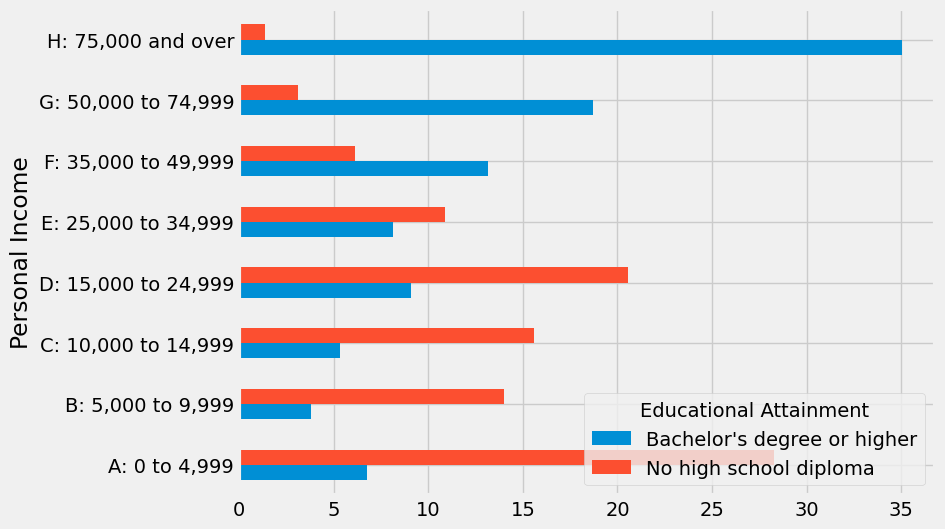

In [17]:
plot_data = distributions.set_index(distributions.columns[0])
plot_data.iloc[:, [0, 3]].plot.barh(figsize=(8,6))
plt.show()